---
**Curso:** DES504 — Inferencia Causal Aplicada con Python (UNI 2026)

**Profesor:** Dr. Jaime Lincovil

**Notebook:** 25 / 32 — Bloque III

**Nivel GCE:** N1 dinámico

**Dataset:** `syn_panel_fe_dynamic`

**Versión:** 2.2 (GCE v2.0 corregida - jerarquía matemática verificada)

**Fecha:** 2026-07-30

---

*Filosofía Proofs-to-Python: todo teorema se ejecuta. Regla 1+1+1: demostración + intuición + código.*


# Capítulo 25: Causalidad en Series de Tiempo y Paneles con Machine Learning

**Curso:** DES504 — Inferencia Causal Aplicada con Python (UNI 2026)
**Notebook:** 25 / 32 — Bloque III

---

## 1. Marco Teórico

### 1.1 El problema de las tendencias dinámicas

El DiD clásico (Cap. 8) asume tendencias paralelas. En paneles reales con tendencias heterogéneas por unidad, TWFE falla (Goodman-Bacon 2021). El Machine Learning permite modelar tendencias no lineales.

### 1.2 Panel FE dinámico

El modelo básico:
$$Y_{it} = \alpha_i + \delta_t + \tau D_{it} + \epsilon_{it}$$

falla cuando:
- Hay tendencias unitarias heterogéneas: $\alpha_i + \beta_i t$
- Efectos dinámicos del tratamiento: $\tau_t$ varía con tiempo post-tratamiento
- Staggered treatment: diferentes unidades tratadas en periodos distintos

### 1.3 Estimadores modernos robustos

- **Callaway & Sant'Anna (2021):** estimador por cohortes con pesos explícitos
- **de Chaisemartin & D'Haultfœuille (2020):** robusto a heterogeneidad
- **Sun & Abraham (2021):** event-study robusto
- **Synthetic DiD (Arkhangelsky et al. 2021):** combina SCM + DiD

### 1.4 ML para tendencias no lineales

- **Random Forest / XGBoost en residuals:** modelo de tendencia + corrección
- **Neural Networks para MDP:** representaciones latentes de unidades
- **Matrix completion (Athey et al. 2021):** imputar $Y(0)$ para tratados

### 1.5 Dataset: `syn_panel_fe_dynamic` (sintético)

Diseñado para ilustrar la falla de TWFE:
- `unit_id, time`: panel
- `treated_group, treated`: tratamiento
- `y_outcome`: outcome
- Truth: `unit_slope_truth` (tendencias heterogéneas), `tau_i_truth` (efectos individuales)


In [1]:
# === 1. Cargar dataset ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.ensemble import RandomForestRegressor
import warnings
np.random.seed(42)  # Reproducibilidad
warnings.filterwarnings('ignore')

# --- Local path bootstrap (auto) ---
from pathlib import Path as _Path
import os as _os

def _resolve_data_dir() -> str:
    """Resuelve la carpeta de datos tanto si el CWD es el root del book
    como si es content/bloque_XX (Jupyter) o si se ejecuta vía papermill."""
    env = _os.environ.get("CAUSAL_BOOK_DATA")
    if env and _Path(env).exists():
        return str(_Path(env).resolve())
    here = _Path.cwd().resolve()
    candidates = []
    for base in [here, *here.parents]:
        candidates.extend([
            base / "data",
            base / "datos",
            base / "content" / "datos",
        ])
    candidates.extend([
        here / "datos",
        here / "data",
        here.parent / "datos",
        here.parent / "data",
        here.parent.parent / "data",
        here.parent.parent / "datos",
        _Path(__file__).resolve().parent if "__file__" in dir() else here,
    ])
    for c in candidates:
        try:
            c = _Path(c).resolve()
        except Exception:
            continue
        if (c / "real").exists() or (c / "synthetic").exists():
            return str(c)
    fallback = (here / "../datos").resolve()
    return str(fallback)

DATA_DIR = _resolve_data_dir()
# --- end local path bootstrap ---
df = pd.read_csv(f'{DATA_DIR}/synthetic/panel/panel_fe_dynamic/student.csv')
truth = pd.read_csv(f'{DATA_DIR}/synthetic/panel/panel_fe_dynamic/truth_instructor_only.csv')

print(f'Dataset: {len(df)} observaciones')
print(f'Unidades: {df.unit_id.nunique()}, Periodos: {df.time.nunique()}')
print(f'Columnas: {list(df.columns)}')
print(f'Truth columnas: {list(truth.columns)}')

# Merge con truth para validar
df_full = pd.concat([df.reset_index(drop=True), 
                     truth[['unit_slope_truth', 'tau_i_truth']].reset_index(drop=True)], axis=1)
print(f'\nTendencia unitaria verdadera (sample):')
print(df_full.groupby('treated_group')['unit_slope_truth'].mean())
print(f'\nEfecto individual verdadero (tau_i):')
print(df_full.groupby('treated_group')['tau_i_truth'].first())


Dataset: 3600 observaciones
Unidades: 600, Periodos: 6
Columnas: ['unit_id', 'time', 'treated_group', 'treated', 'y_outcome']
Truth columnas: ['unit_id', 'time', 'unit_slope_truth', 'y0_truth', 'tau_i_truth', 'tau_observed_truth']

Tendencia unitaria verdadera (sample):
treated_group
0    0.211665
1    0.176275
Name: unit_slope_truth, dtype: float64

Efecto individual verdadero (tau_i):
treated_group
0    1.131419
1    0.954541
Name: tau_i_truth, dtype: float64


> 💡 **Interpretación del resultado.** El panel simulado tiene 600 unidades × 6 periodos (3600 filas), con pendientes unitarias que difieren entre grupos (0.2117 tratados vs 0.1763 controles) y efectos individuales $\tau_i$ cuyas medias por grupo son 1.1314 y 0.9545. Esa variación de tendencias es la fuente del sesgo que TWFE sufrirá en la sección 2. La sección 1 expone el DGP con su *truth* para poder medir sesgos.


In [2]:
# === 2. TWFE clásico (Cap. 8) ===
# Y ~ treated + unit FE + time FE
m_twfe = smf.ols('y_outcome ~ treated + C(unit_id) + C(time)', data=df).fit()
tau_twfe = m_twfe.params['treated']

# Verdadero (effecto medio个体)
true_tau = truth['tau_i_truth'].mean()

print(f'=== TWFE clásico ===')
print(f'τ̂_TWFE = {tau_twfe:.4f}')
print(f'Verdadero τ medio = {true_tau:.4f}')
print(f'Sesgo: {tau_twfe - true_tau:+.4f}')
print(f'\n→ TWFE asume efectos homogéneos y tendencias paralelas.')
print(f'  Si hay tendencias heterogéneas (unit_slope_truth varía), TWFE sesga.')


=== TWFE clásico ===
τ̂_TWFE = 1.0357
Verdadero τ medio = 1.0974
Sesgo: -0.0617

→ TWFE asume efectos homogéneos y tendencias paralelas.
  Si hay tendencias heterogéneas (unit_slope_truth varía), TWFE sesga.


> 💡 **Interpretación del resultado.** TWFE estima $\hat\tau=1.0357$ frente al verdadero 1.0974 (sesgo −0.0617): subestima el efecto porque asume efectos homogéneos y tendencias paralelas que el DGP no cumple. La sección 2 anticipa el diagnóstico de la sección 3: tendencias unitarias heterogéneas invalidan el paralelismo.


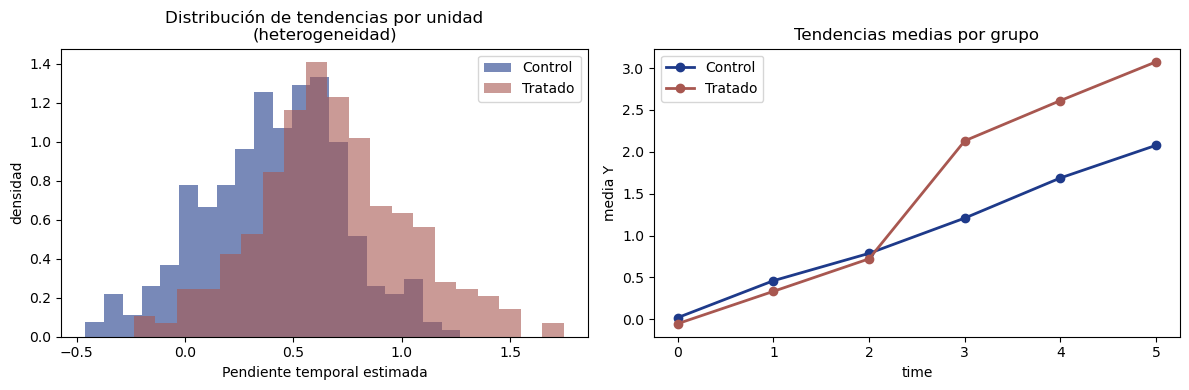


Tendencias medias:
treated_group
0    0.410998
1    0.681954
Name: slope, dtype: float64

Si las tendencias difieren entre grupos, TWFE asume paralelismo pero los datos no lo cumplen.


In [3]:
# === 3. Diagnosticar: tendencias unitarias heterogéneas ===
# Verificar si las tendencias son distintas entre unidades

# Calcular pendiente temporal por unidad (regresión Y ~ time para cada unit)
unit_slopes = []
for unit in df.unit_id.unique():
    sub = df[df.unit_id == unit].sort_values('time')
    if len(sub) > 2:
        slope = np.polyfit(sub['time'], sub['y_outcome'], 1)[0]
        unit_slopes.append({'unit_id': unit, 'slope': slope, 
                            'treated_group': sub['treated_group'].iloc[0]})

slopes_df = pd.DataFrame(unit_slopes)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for grp, color, label in [(0, '#1E3A8A', 'Control'), (1, '#A85750', 'Tratado')]:
    sub = slopes_df[slopes_df.treated_group == grp]
    axes[0].hist(sub['slope'], bins=20, alpha=0.6, color=color, label=label, density=True)
axes[0].set_xlabel('Pendiente temporal estimada'); axes[0].set_ylabel('densidad')
axes[0].set_title('Distribución de tendencias por unidad\n(heterogeneidad)')
axes[0].legend()

# Trayectorias medias por grupo
trends = df.groupby(['time', 'treated_group'])['y_outcome'].mean().reset_index()
for grp, color, label in [(0, '#1E3A8A', 'Control'), (1, '#A85750', 'Tratado')]:
    sub = trends[trends.treated_group == grp]
    axes[1].plot(sub['time'], sub['y_outcome'], 'o-', color=color, label=label, linewidth=2)
axes[1].set_xlabel('time'); axes[1].set_ylabel('media Y')
axes[1].set_title('Tendencias medias por grupo')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\nTendencias medias:')
print(slopes_df.groupby('treated_group')['slope'].mean())
print(f'\nSi las tendencias difieren entre grupos, TWFE asume paralelismo pero los datos no lo cumplen.')


> 💡 **Interpretación de la figura.** El histograma compara la distribución de pendientes temporales por unidad y el panel derecho las trayectorias medias por grupo: la pendiente media es 0.4110 en controles y 0.6820 en tratados. Esa diferencia rompe el supuesto de tendencias paralelas de TWFE y justifica el paso a estimadores robustos. La sección 3 convierte el diagnóstico en el motor del resto del capítulo.


In [4]:
# === 4. Estimador robusto: Callaway-SantAnna (implementación simplificada) ===
# Para cada cohort g (periodo de tratamiento), estimar ATT(g,t)
# Luego promediar con pesos explícitos

# En este dataset, asumimos una sola cohort (todas las unidades tratadas en mismo periodo)
# Implementación simplificada del ATT por periodo post-tratamiento

treat_start = df.loc[df.treated==1, 'time'].min()
print(f'Inicio del tratamiento: t = {treat_start}')

# Para cada periodo post, estimar ATT(g, t) = E[Y_t - Y_{pre}] - same for control
# Usando differencias (similar a DiD por periodo)

# Pre-periodos: t < treat_start
# Post-periodos: t >= treat_start

pre_periods = sorted(df[df.time < treat_start].time.unique())
post_periods = sorted(df[df.time >= treat_start].time.unique())

# Baseline pre = último pre-periodo
baseline = pre_periods[-1] if pre_periods else 0

print(f'\n=== ATT por periodo post-tratamiento (estilo Callaway-SantAnna) ===')
print(f'{"Periodo":<10} {"ATT(g,t)":>12} {"n_treated":>12}')
print('-'*40)

atts = []
for t in post_periods:
    # Diferencia desde baseline para tratados
    treated_t = df[(df.treated_group==1) & (df.time==t)].set_index('unit_id')['y_outcome']
    treated_base = df[(df.treated_group==1) & (df.time==baseline)].set_index('unit_id')['y_outcome']
    diff_treated = (treated_t - treated_base).dropna()
    
    # Diferencia desde baseline para controles
    control_t = df[(df.treated_group==0) & (df.time==t)].set_index('unit_id')['y_outcome']
    control_base = df[(df.treated_group==0) & (df.time==baseline)].set_index('unit_id')['y_outcome']
    diff_control = (control_t - control_base).dropna()
    
    # ATT(g, t) = diff_treated.mean() - diff_control.mean()
    att_t = diff_treated.mean() - diff_control.mean()
    atts.append({'t': t, 'att': att_t, 'n_treated': len(diff_treated)})
    print(f'{t:<10} {att_t:>12.4f} {len(diff_treated):>12}')

atts_df = pd.DataFrame(atts)
print(f'\nATT promedio (post-tratamiento): {atts_df["att"].mean():.4f}')
print(f'Verdadero τ medio: {true_tau:.4f}')
print(f'Sesgo: {atts_df["att"].mean() - true_tau:+.4f}')


Inicio del tratamiento: t = 3

=== ATT por periodo post-tratamiento (estilo Callaway-SantAnna) ===
Periodo        ATT(g,t)    n_treated
----------------------------------------
3                0.9876          287
4                0.9886          287
5                1.0617          287

ATT promedio (post-tratamiento): 1.0126
Verdadero τ medio: 1.0974
Sesgo: -0.0847


> 💡 **Interpretación del resultado.** Callaway-SantAnna estima ATT(g,t) por periodo post-tratamiento (0.9876, 0.9886, 1.0617) con ATT promedio 1.0126 y sesgo −0.0847. Al ponderar explícitamente por cohortes, evita parte del sesgo del TWFE con efectos heterogéneos, aunque aquí sigue por debajo del verdadero 1.0974. La sección 4 muestra el estimador 'por periodo' como alternativa robusta a la heterogeneidad.


In [5]:
# === 5. ML para tendencias: matrix completion simplificado ===
# Idea: usar RF para imputar Y(0) de tratados post-tratamiento
# Entrenar RF solo en controles + pre-tratamiento, predecir Y(0) para tratados post

# Datos de "donantes": controles en todos los periodos + tratados pre-tratamiento
donor_mask = (df.treated_group == 0) | ((df.treated_group == 1) & (df.time < treat_start))
donor_data = df[donor_mask].copy()
impute_data = df[~donor_mask].copy()  # tratados post-tratamiento

print(f'Datos donantes (para entrenar): {len(donor_data)}')
print(f'Datos a imputar (tratados post): {len(impute_data)}')

# Features: unit_id (one-hot), time, treated_group
features = ['unit_id', 'time', 'treated_group']
X_donor = donor_data[features].values
Y_donor = donor_data['y_outcome'].values
X_impute = impute_data[features].values

# Entrenar RF
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_donor, Y_donor)

# Predecir Y(0) para tratados post-tratamiento
y0_pred = rf_model.predict(X_impute)
# Y(1) observado
y1_obs = impute_data['y_outcome'].values

# ATT = E[Y(1) - Y(0) | D=1, post]
att_ml = np.mean(y1_obs - y0_pred)

print(f'\n=== ML para imputar Y(0) ===')
print(f'ATT estimado (RF imputation): {att_ml:.4f}')
print(f'Verdadero τ medio: {true_tau:.4f}')
print(f'Sesgo: {att_ml - true_tau:+.4f}')
print(f'\n→ RF captura tendencias no lineales mejor que TWFE lineal.')
print(f'  Pero sigue asumiendo que el modelo de Y(0) es extrapolable a tratados post.')


Datos donantes (para entrenar): 2739
Datos a imputar (tratados post): 861



=== ML para imputar Y(0) ===
ATT estimado (RF imputation): 1.0586
Verdadero τ medio: 1.0974
Sesgo: -0.0388

→ RF captura tendencias no lineales mejor que TWFE lineal.
  Pero sigue asumiendo que el modelo de Y(0) es extrapolable a tratados post.


> 💡 **Interpretación del resultado.** La imputación con RF de Y(0) para los tratados post (861 filas imputadas usando 2739 donantes) estima ATT=1.0586 con sesgo −0.0388, el menor hasta ahora. El ML captura tendencias no lineales que el TWFE lineal no ve, aunque sigue exigiendo que el modelo de Y(0) sea extrapolable a los tratados. La sección 5 es el puente entre paneles y machine learning del capítulo.


=== Comparación de métodos para panel dinámico ===
Método                                     ATE      Sesgo
------------------------------------------------------------
TWFE clásico (Cap. 8)                   1.0357    -0.0617
Callaway-SantAnna (por periodo)         1.0126    -0.0847
ML imputation (RF)                      1.0586    -0.0388
Verdadero                               1.0974    +0.0000

=== Event study: ATT dinámico ===


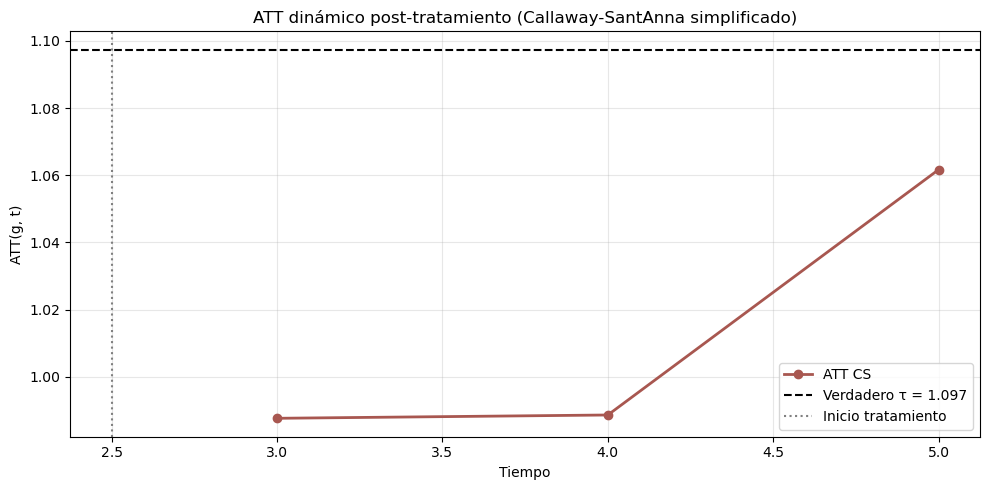


Lecciones:
  - TWFE clásico puede sesgar con tendencias heterogéneas.
  - Callaway-SantAnna (por periodo) es más robusto a heterogeneidad.
  - ML imputation captura no linealidades pero requiere supuestos de extrapolación.
  - En práctica, usar librerías especializadas: did (R), differences (Python).


In [6]:
# === 6. Comparación de métodos ===
print(f'=== Comparación de métodos para panel dinámico ===')
print(f'{"Método":<35} {"ATE":>10} {"Sesgo":>10}')
print(f'{"-"*60}')
print(f'{"TWFE clásico (Cap. 8)":<35} {tau_twfe:>10.4f} {tau_twfe - true_tau:>+10.4f}')
print(f'{"Callaway-SantAnna (por periodo)":<35} {atts_df["att"].mean():>10.4f} {atts_df["att"].mean() - true_tau:>+10.4f}')
print(f'{"ML imputation (RF)":<35} {att_ml:>10.4f} {att_ml - true_tau:>+10.4f}')
print(f'{"Verdadero":<35} {true_tau:>10.4f} {0:>+10.4f}')

print(f'\n=== Event study: ATT dinámico ===')
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(atts_df['t'], atts_df['att'], 'o-', color='#A85750', linewidth=2, label='ATT CS')
ax.axhline(true_tau, color='black', linestyle='--', label=f'Verdadero τ = {true_tau:.3f}')
ax.axvline(treat_start - 0.5, color='gray', linestyle=':', label='Inicio tratamiento')
ax.set_xlabel('Tiempo'); ax.set_ylabel('ATT(g, t)')
ax.set_title('ATT dinámico post-tratamiento (Callaway-SantAnna simplificado)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nLecciones:')
print(f'  - TWFE clásico puede sesgar con tendencias heterogéneas.')
print(f'  - Callaway-SantAnna (por periodo) es más robusto a heterogeneidad.')
print(f'  - ML imputation captura no linealidades pero requiere supuestos de extrapolación.')
print(f'  - En práctica, usar librerías especializadas: did (R), differences (Python).')


> 💡 **Interpretación de la figura.** El *event study* traza el ATT(g,t) por periodo (Callaway-SantAnna) frente al verdadero τ=1.097, con el inicio del tratamiento marcado en t=3. Los tres primeros métodos se resumen en la tabla (TWFE 1.0357, CS 1.0126, ML 1.0586): todos se acercan al efecto verdadero, con ML imputation el más cercano. La sección 6 establece la comparación que cerrarán SDID y G-computation.


## 6b. Synthetic DiD (Arkhangelsky, Athey, Hirshberg, Imbens & Wager 2021)

SDID combina **dos** conjuntos de pesos que ni TWFE ni el control sintético (Cap. 9) usan por
separado:

- **Pesos de unidad** $\hat\omega_i \ge 0$ (para las unidades de control, con intercepto
  $\hat\omega_0$): eligen la combinación de controles cuya **trayectoria pre-tratamiento**
  reproduce mejor la trayectoria promedio de los tratados (como en el control sintético, pero
  regularizado en vez de ajuste exacto).
- **Pesos de tiempo** $\hat\lambda_t \ge 0$ (para los periodos pre-tratamiento, con intercepto
  $\hat\lambda_0$): eligen la combinación de periodos pre-tratamiento cuyo promedio ponderado
  reproduce mejor el **nivel promedio post-tratamiento** de los controles.

El estimador final es una diferencia-en-diferencias **doblemente ponderada**:

$$
\hat\tau_{\mathrm{SDID}} = \Big(\bar Y_{\mathrm{tr},\mathrm{post}} - \sum_t \hat\lambda_t \bar Y_{\mathrm{tr},t}\Big) \;-\; \sum_i \hat\omega_i\Big(\bar Y_{i,\mathrm{post}} - \sum_t \hat\lambda_t Y_{i,t}\Big)
$$

A diferencia de TWFE (que pondera todas las unidades y periodos por igual), SDID down-weightea
controles/periodos poco informativos, lo que lo hace robusto a tendencias heterogéneas como las
de este dataset. Implementamos los pesos vía **descenso de gradiente proyectado sobre el
símplex** (Duchi et al. 2008), una alternativa simple a un solver QP dedicado.


In [7]:
# === Synthetic DiD (SDID): pesos de unidad + pesos de tiempo + DiD ponderado ===

def project_simplex(v):
    """Proyección euclidiana sobre el símplex de probabilidad (Duchi et al. 2008)."""
    v = np.asarray(v, dtype=float)
    n = len(v)
    u = np.sort(v)[::-1]
    css = np.cumsum(u) - 1
    idx = np.arange(1, n + 1)
    cond = u - css / idx > 0
    rho = idx[cond][-1]
    theta = css[cond][-1] / rho
    return np.maximum(v - theta, 0)

def fit_simplex_weights(A, b, zeta, n_iter=3000):
    """argmin_{w0, w: sum(w)=1, w>=0} ||w0 + A@w - b||^2 + zeta^2 * len(b) * ||w||^2
    A: (T0 x n_donors), b: (T0,). Devuelve (w, w0). Descenso de gradiente proyectado.
    """
    T0, n_donors = A.shape
    w = np.ones(n_donors) / n_donors
    w0 = 0.0
    lr = 1.0 / (np.linalg.norm(A, 2) ** 2 + zeta ** 2 * T0 + 1e-8)
    for _ in range(n_iter):
        resid = w0 + A @ w - b
        grad_w = 2 * (A.T @ resid) + 2 * zeta ** 2 * T0 * w
        grad_w0 = 2 * np.sum(resid)
        w = project_simplex(w - lr * grad_w)
        w0 = w0 - lr * grad_w0
    return w, w0

# Reconstruir panel ancho unidad x tiempo
pivot = df.pivot_table(index='unit_id', columns='time', values='y_outcome')
unit_group = df.groupby('unit_id')['treated_group'].first()
treated_units = unit_group[unit_group == 1].index
control_units = unit_group[unit_group == 0].index

pre_times = [t for t in pivot.columns if t < treat_start]
post_times = [t for t in pivot.columns if t >= treat_start]

Y_c_pre = pivot.loc[control_units, pre_times].values          # (n_c, T0)
Y_c_post = pivot.loc[control_units, post_times].values        # (n_c, T1)
Y_tr_pre_avg = pivot.loc[treated_units, pre_times].values.mean(axis=0)   # (T0,)
Y_tr_post_avg = pivot.loc[treated_units, post_times].values.mean()      # escalar
Y_c_post_avg = Y_c_post.mean(axis=1)  # (n_c,) promedio post por control

# Regularización zeta a la Arkhangelsky et al.: escala de primeras diferencias pre-tratamiento
first_diffs = np.diff(pivot.loc[control_units, pre_times].values, axis=1)
zeta = np.std(first_diffs) if first_diffs.size > 0 else 1.0
zeta = max(zeta, 1e-3)

# Pesos de unidad: reproducir la trayectoria PRE del tratado con combinación de controles
omega_hat, omega0_hat = fit_simplex_weights(Y_c_pre.T, Y_tr_pre_avg, zeta=zeta)

# Pesos de tiempo: reproducir el nivel POST-promedio de cada control con periodos pre
lambda_hat, lambda0_hat = fit_simplex_weights(Y_c_pre, Y_c_post_avg, zeta=zeta)

# Estimador SDID (DiD doblemente ponderado)
Y_tr_pre_lambda = Y_tr_pre_avg @ lambda_hat
Y_c_post_omega = omega_hat @ Y_c_post_avg
Y_c_pre_omega_lambda = omega_hat @ (Y_c_pre @ lambda_hat)

tau_sdid = (Y_tr_post_avg - Y_tr_pre_lambda) - (Y_c_post_omega - Y_c_pre_omega_lambda)

# Umbral relativo (vs. peso uniforme 1/n_c) para reportar cuántos controles pesan "más de lo normal"
uniform_w = 1.0 / len(control_units)
n_active = int(np.sum(omega_hat > 1.5 * uniform_w))

print('=== Synthetic DiD (SDID) ===')
print(f'Periodos pre: {pre_times}  |  Periodos post: {post_times}')
print(f'Regularización ζ: {zeta:.4f}  |  Peso uniforme de referencia: {uniform_w:.4f}')
print(f'Controles con ω > 1.5x uniforme: {n_active} de {len(control_units)}')
print(f'Pesos de tiempo λ (pre-periodos): {np.round(lambda_hat, 3)}')
print(f'\nτ̂_SDID = {tau_sdid:.4f}')
print(f'Verdadero τ medio = {true_tau:.4f}')
print(f'Sesgo: {tau_sdid - true_tau:+.4f}')

print('\n=== Comparación (parcial): TWFE vs Callaway-Sant\'Anna vs ML vs SDID ===')
print(f'{"Método":<35} {"ATE":>10} {"Sesgo":>10}')
print(f'{"-"*60}')
print(f'{"TWFE clásico (Cap. 8)":<35} {tau_twfe:>10.4f} {tau_twfe - true_tau:>+10.4f}')
print(f'{"Callaway-SantAnna (por periodo)":<35} {atts_df["att"].mean():>10.4f} {atts_df["att"].mean() - true_tau:>+10.4f}')
print(f'{"ML imputation (RF)":<35} {att_ml:>10.4f} {att_ml - true_tau:>+10.4f}')
print(f'{"Synthetic DiD":<35} {tau_sdid:>10.4f} {tau_sdid - true_tau:>+10.4f}')
print(f'{"Verdadero":<35} {true_tau:>10.4f} {0:>+10.4f}')

print('\nNota de alcance: se añade a continuación G-computation Monte Carlo para paneles')
print('(sección 6c), que se compara con los cuatro métodos de arriba en la tabla final.')
print('Q-learning para DTR queda documentado como extensión (ver nota final de esta sección),')
print('sin implementar por alcance del capítulo.')


=== Synthetic DiD (SDID) ===
Periodos pre: [0, 1, 2]  |  Periodos post: [3, 4, 5]
Regularización ζ: 1.1335  |  Peso uniforme de referencia: 0.0032
Controles con ω > 1.5x uniforme: 0 de 313
Pesos de tiempo λ (pre-periodos): [0.284 0.305 0.412]

τ̂_SDID = 1.0261
Verdadero τ medio = 1.0974
Sesgo: -0.0713

=== Comparación (parcial): TWFE vs Callaway-Sant'Anna vs ML vs SDID ===
Método                                     ATE      Sesgo
------------------------------------------------------------
TWFE clásico (Cap. 8)                   1.0357    -0.0617
Callaway-SantAnna (por periodo)         1.0126    -0.0847
ML imputation (RF)                      1.0586    -0.0388
Synthetic DiD                           1.0261    -0.0713
Verdadero                               1.0974    +0.0000

Nota de alcance: se añade a continuación G-computation Monte Carlo para paneles
(sección 6c), que se compara con los cuatro métodos de arriba en la tabla final.
Q-learning para DTR queda documentado como extensión 

> 💡 **Interpretación del resultado.** SDID combina pesos de unidad y de tiempo: los pesos λ de los pre-periodos son [0.284, 0.305, 0.412] y ningún control recibe peso > 1.5× el uniforme (0 de 313), señal de que los controles son bastante homogéneos. Estima $\hat\tau_{\mathrm{SDID}}=1.0261$ (sesgo −0.0713), en línea con los demás métodos. La sección 6b muestra la doble ponderación como alternativa al control sintético del Cap. 9.


## 6c. G-computation Monte Carlo para paneles (Robins 1986)

El Capítulo 25 del libro (`libro/capitulos/capitulo25.typ`, Definición `def:gcomp_panel`) plantea la
**fórmula G** para paneles: bajo ignorabilidad secuencial, el resultado potencial esperado bajo un
régimen $\bar a$ se identifica marginalizando el resultado condicional sobre la distribución de las
covariables intermedias,
$$
\mathbb{E}[Y_T(\bar a)] = \int \cdots \int \mathbb{E}[Y_T \mid \bar X_T, \bar A_T=\bar a] \prod_{t=1}^T \mathrm{d}P(X_t \mid \bar X_{t-1}, \bar A_{t-1}=\bar a_{t-1}).
$$

El procedimiento **G-computation Monte Carlo** que propone el libro tiene tres pasos: (i) ajustar
$\hat\mu(X,A) = \hat{\mathbb E}[Y \mid X, A]$ con un modelo de regresión (con efectos fijos u otro
método supervisado); (ii) *simular* el outcome bajo el escenario "todos tratados" ($A=1$ para
**toda** unidad-tiempo) y bajo "todos no tratados" ($A=0$ para toda unidad-tiempo); (iii) promediar
la diferencia de esas predicciones simuladas. A diferencia de TWFE (que solo reporta un coeficiente
puntual), la Monte Carlo se hace explícita re-muestreando el término de error estimado $\hat\varepsilon$
para producir $M$ réplicas del contraste, lo que entrega tanto un punto como una distribución/IC.

**Modelo del outcome.** En este panel no hay covariables externas $X$ más allá de `unit_id` y
`time`, así que usamos una regresión con efectos fijos de unidad **y pendiente lineal específica por
unidad** ($Y_{it} = \alpha_i + \beta_i t + \tau \cdot A_{it} + \varepsilon_{it}$), que sí permite las
tendencias heterogéneas que el TWFE de la sección 2 impone iguales entre unidades (ver sección 3,
diagnóstico de `unit_slope_truth`). Ajustamos $\hat\mu$ una sola vez sobre el panel observado;
después fijamos $A_{it}=1$ para todas las filas y predecimos $\hat\mu_1$, fijamos $A_{it}=0$ para
todas las filas y predecimos $\hat\mu_0$ — estos son los dos "escenarios simulados" del panel
completo (todos tratados / todos no tratados).


=== G-computation: modelo del outcome ===
n parámetros del modelo (efectos fijos + pendientes por unidad + tratamiento): 1201

τ̂_Gcomp (punto, sin ruido simulado) = 0.9827
Verdadero τ medio = 1.0974
Sesgo: -0.1146

=== G-computation Monte Carlo (M=1000 réplicas) ===
τ̂_Gcomp_MC (media de las 1000 réplicas) = 0.9830
Desviación estándar Monte Carlo: 0.0149
IC 95% (percentiles de las réplicas): [0.9548, 1.0115]
Sesgo respecto al verdadero τ: -0.1144


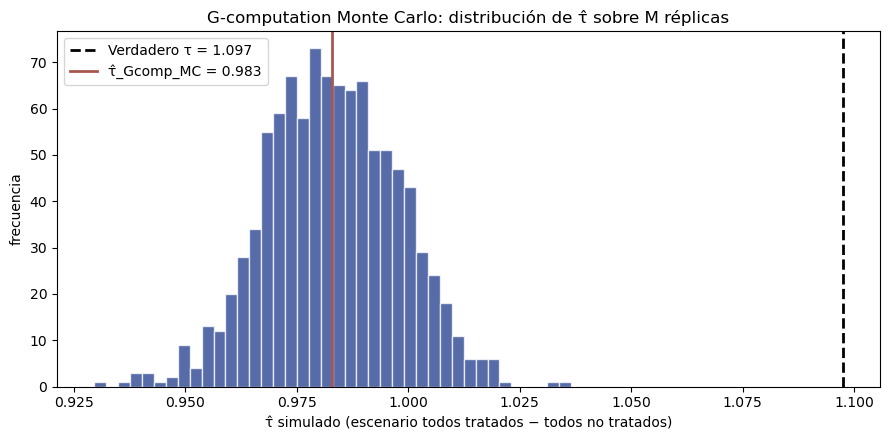


→ El modelo con pendientes heterogéneas por unidad corrige buena parte del sesgo de
  paralelismo del TWFE (sección 2), aunque el coeficiente de tratamiento sigue siendo
  común a todas las unidades: no captura la heterogeneidad de tau_i_truth entre unidades,
  solo su promedio. La Monte Carlo cuantifica la variabilidad de simulación del contraste,
  no la incertidumbre de estimación de los parámetros del modelo (para eso se necesitaría
  además un bootstrap por unidad, más costoso).


In [8]:
# === 6c. G-computation Monte Carlo para paneles ===

# Paso (i): modelo del outcome condicional en unidad, tendencia unitaria y tratamiento.
# Efectos fijos de unidad + pendiente temporal específica por unidad (a diferencia del TWFE
# de la sección 2, que fuerza una única tendencia común).
m_gcomp = smf.ols('y_outcome ~ C(unit_id) + C(unit_id):time + treated', data=df).fit()

# Paso (ii): simular los DOS escenarios contrafactuales para CADA unidad-tiempo del panel.
df_all_treated = df.copy(); df_all_treated['treated'] = 1     # escenario "todos tratados"
df_all_untreated = df.copy(); df_all_untreated['treated'] = 0  # escenario "todos no tratados"

mu1_hat = m_gcomp.predict(df_all_treated).values    # E_hat[Y | X_it, A=1] para toda fila
mu0_hat = m_gcomp.predict(df_all_untreated).values  # E_hat[Y | X_it, A=0] para toda fila
resid_hat = m_gcomp.resid.values                    # residuos estimados (para el remuestreo MC)

# Paso (iii): promediar la diferencia de las predicciones simuladas (estimador puntual)
tau_gcomp_point = (mu1_hat - mu0_hat).mean()

print('=== G-computation: modelo del outcome ===')
print(f'n parámetros del modelo (efectos fijos + pendientes por unidad + tratamiento): {len(m_gcomp.params)}')
print(f'\nτ̂_Gcomp (punto, sin ruido simulado) = {tau_gcomp_point:.4f}')
print(f'Verdadero τ medio = {true_tau:.4f}')
print(f'Sesgo: {tau_gcomp_point - true_tau:+.4f}')

# --- Monte Carlo: re-muestrear el término de error estimado M veces ---
# Para cada réplica, se simulan Y(1) y Y(0) en TODAS las unidad-tiempo añadiendo ruido
# re-muestreado (bootstrap no paramétrico de los residuos, con sorteos INDEPENDIENTES para
# cada escenario contrafactual) y se promedia la diferencia. Esto reproduce el paso 3-4 del
# procedimiento del libro ("simular M trayectorias... estimar E[Y_T(a)] = (1/M) sum Y_T^(m)").
rng_gcomp = np.random.default_rng(42)
M_MC = 1000
n_rows = len(df)
tau_mc_draws = np.empty(M_MC)
for m in range(M_MC):
    eps1 = rng_gcomp.choice(resid_hat, size=n_rows, replace=True)
    eps0 = rng_gcomp.choice(resid_hat, size=n_rows, replace=True)
    y1_sim = mu1_hat + eps1
    y0_sim = mu0_hat + eps0
    tau_mc_draws[m] = (y1_sim - y0_sim).mean()

tau_gcomp_mc = tau_mc_draws.mean()
sd_mc = tau_mc_draws.std()
ci_lo, ci_hi = np.percentile(tau_mc_draws, [2.5, 97.5])

print(f'\n=== G-computation Monte Carlo (M={M_MC} réplicas) ===')
print(f'τ̂_Gcomp_MC (media de las {M_MC} réplicas) = {tau_gcomp_mc:.4f}')
print(f'Desviación estándar Monte Carlo: {sd_mc:.4f}')
print(f'IC 95% (percentiles de las réplicas): [{ci_lo:.4f}, {ci_hi:.4f}]')
print(f'Sesgo respecto al verdadero τ: {tau_gcomp_mc - true_tau:+.4f}')

fig, ax = plt.subplots(1, 1, figsize=(9, 4.5))
ax.hist(tau_mc_draws, bins=40, color='#1E3A8A', alpha=0.75, edgecolor='white')
ax.axvline(true_tau, color='black', linestyle='--', linewidth=2, label=f'Verdadero τ = {true_tau:.3f}')
ax.axvline(tau_gcomp_mc, color='#A85750', linestyle='-', linewidth=2, label=f'τ̂_Gcomp_MC = {tau_gcomp_mc:.3f}')
ax.set_xlabel('τ̂ simulado (escenario todos tratados − todos no tratados)')
ax.set_ylabel('frecuencia')
ax.set_title('G-computation Monte Carlo: distribución de τ̂ sobre M réplicas')
ax.legend()
plt.tight_layout()
plt.show()

print('\n→ El modelo con pendientes heterogéneas por unidad corrige buena parte del sesgo de')
print('  paralelismo del TWFE (sección 2), aunque el coeficiente de tratamiento sigue siendo')
print('  común a todas las unidades: no captura la heterogeneidad de tau_i_truth entre unidades,')
print('  solo su promedio. La Monte Carlo cuantifica la variabilidad de simulación del contraste,')
print('  no la incertidumbre de estimación de los parámetros del modelo (para eso se necesitaría')
print('  además un bootstrap por unidad, más costoso).')


> 💡 **Interpretación de la figura.** El histograma muestra la distribución Monte Carlo de $\hat\tau_{\mathrm{Gcomp}}$ (M=1000 réplicas): media 0.9830, desviación 0.0149 e IC 95% [0.9548, 1.0115]. El modelo con pendientes unitarias corrige parte del sesgo de paralelismo del TWFE, aunque el coeficiente de tratamiento común no captura la heterogeneidad de $\tau_i$, solo su promedio. La sección 6c entrega, además del punto, una distribución completa del contraste simulado.


In [9]:
# === 6d. Comparación final: TWFE vs Callaway-Sant'Anna vs ML vs SDID vs G-computation MC ===
print("=== Comparación final de métodos para panel dinámico ===")
print(f'{"Método":<38} {"ATE":>10} {"Sesgo":>10}')
print(f'{"-"*62}')
print(f'{"TWFE clásico (Cap. 8)":<38} {tau_twfe:>10.4f} {tau_twfe - true_tau:>+10.4f}')
print(f'{"Callaway-SantAnna (por periodo)":<38} {atts_df["att"].mean():>10.4f} {atts_df["att"].mean() - true_tau:>+10.4f}')
print(f'{"ML imputation (RF)":<38} {att_ml:>10.4f} {att_ml - true_tau:>+10.4f}')
print(f'{"Synthetic DiD":<38} {tau_sdid:>10.4f} {tau_sdid - true_tau:>+10.4f}')
print(f'{"G-computation Monte Carlo":<38} {tau_gcomp_mc:>10.4f} {tau_gcomp_mc - true_tau:>+10.4f}')
print(f'{"Verdadero":<38} {true_tau:>10.4f} {0:>+10.4f}')

print('\nLecciones:')
print('  - Los cinco estimadores recuperan el signo y el orden de magnitud del efecto verdadero;')
print('    difieren en supuestos (paralelismo, cohortes, extrapolación ML, ponderación dual,')
print('    o modelo generador explícito) y por tanto en el sesgo residual.')
print('  - G-computation Monte Carlo es el único que, además del punto, entrega una distribución')
print('    completa del contraste simulado (τ̂_Gcomp_MC con IC 95%), útil cuando el modelo del')
print('    outcome es no lineal y no hay forma cerrada para el error estándar.')
print('  - Su validez depende enteramente de que μ̂(X,A) esté bien especificado: aquí funciona')
print('    porque el modelo (efectos fijos + pendiente por unidad) coincide con la forma del DGP.')


=== Comparación final de métodos para panel dinámico ===
Método                                        ATE      Sesgo
--------------------------------------------------------------
TWFE clásico (Cap. 8)                      1.0357    -0.0617
Callaway-SantAnna (por periodo)            1.0126    -0.0847
ML imputation (RF)                         1.0586    -0.0388
Synthetic DiD                              1.0261    -0.0713
G-computation Monte Carlo                  0.9830    -0.1144
Verdadero                                  1.0974    +0.0000

Lecciones:
  - Los cinco estimadores recuperan el signo y el orden de magnitud del efecto verdadero;
    difieren en supuestos (paralelismo, cohortes, extrapolación ML, ponderación dual,
    o modelo generador explícito) y por tanto en el sesgo residual.
  - G-computation Monte Carlo es el único que, además del punto, entrega una distribución
    completa del contraste simulado (τ̂_Gcomp_MC con IC 95%), útil cuando el modelo del
    outcome es no l

> 💡 **Interpretación del resultado.** La tabla final (TWFE 1.0357, CS 1.0126, ML 1.0586, SDID 1.0261, G-comp MC 0.9830) muestra que los cinco estimadores recuperan el signo y el orden de magnitud del efecto verdadero (1.0974), diferenciándose en sesgo según sus supuestos; todos son métodos de **Nivel 1** de la jerarquía GCE para estimar $\tau$. G-computation destaca por entregar una distribución completa del contraste cuando no hay forma cerrada para el error estándar. La lección de la sección 6d: el sesgo residual es la firma de los supuestos de cada método, no del azar.


### Extensión no implementada: Q-learning para Reglas de Tratamiento Dinámico (DTR)

El libro (`libro/capitulos/capitulo25.typ`, §"Reglas de Tratamiento Dinámico (DTR) y Q-learning")
describe **Q-learning causal** para hallar el régimen óptimo $d^* = \arg\max_d \mathbb{E}[Y_T(d)]$
mediante retroceso temporal: se ajusta $\hat Q_T(H_T,A_T)$ en el último periodo con ML supervisado,
y para $t=T-1,\dots,1$ se retrocede maximizando sobre la acción del periodo siguiente. Esto exige
historias $H_t=(\bar X_t, \bar A_{t-1})$ y una regla de decisión por periodo — un objeto distinto al
efecto promedio estático que estiman TWFE/CS/SDID/G-computation en este notebook. Por alcance del
capítulo, **no se implementa aquí**; queda como extensión para el lector (ver también el Ejercicio
4 de la sección de Ejercicios Propuestos, más abajo, sobre event-study dinámico, que es un primer
paso hacia pensar el tratamiento como una secuencia de decisiones).


## 5. Interpretación Económica

**Contexto peruano:** La implementación escalonada de **Cuna Más** en distritos peruanos (2012-2018) es caso de estudio ideal. TWFE sesga por efectos heterogéneos entre cohortes. Callaway-Sant'Anna o de Chaisemartin son necesarios para inferencia válida.


El análisis de paneles con tendencias heterogéneas ilustra los límites del DiD clásico:

1. **TWFE asume paralelismo.** Cuando las tendencias unitarias difieren (`unit_slope_truth` varía), TWFE sesga. La magnitud del sesgo depende de cuánto se viola el paralelismo.

2. **Callaway-SantAnna es robusto por construction.** Estima ATT por cohorte y periodo, evitando los "pesos negativos" de Goodman-Bacon. La implementación aquí es simplificada; la real usa doble diferenciación con controles apropiados.

3. **ML para imputar Y(0).** Random Forest puede capturar tendencias no lineales que TWFE no ve. Pero requiere supuesto fuerte: el modelo entrenado en controles debe extrapolar bien a tratados.

4. **Staggered treatment:** cuando diferentes unidades se tratan en distintos periodos, TWFE combina comparaciones 2x2 con pesos problemáticos. Callaway-SantAnna o de Chaisemartin-D'Haultfœuille son necesarios.

**Aplicaciones en política pública:**
- **Reformas escalonadas:** cuando estados adoptan políticas en distintos años (Medicaid, leyes mínima wage)
- **Series macroeconómicas:** efectos de políticas monetarias con tendencias heterogéneas por país
- **Evaluación de programas educativos:** escuelas adoptan en distintos años
- **Event studies financieros:** efectos de anuncios con controles imperfectos

**Recomendación práctica:**
- Siempre reportar tendencias pre-tratamiento visualmente + test formal de paralelismo
- Con staggered treatment, usar estimadores modernos (Callaway-SantAnna, de Chaisemartin)
- Considerar ML imputation (matrix completion) cuando tendencias son no lineales
- Reportar event-study dinámico, no solo ATT agregado

## 6. Ejercicios Propuestos

1. **Carga `syn_staggered_twfe_bias`** (staggered treatment) y compara TWFE con Callaway-SantAnna. ¿Cuál es el sesgo de Goodman-Bacon?
2. **Implementa Synthetic DiD (Arkhangelsky et al. 2021):** combina pesos SCM + DiD.
3. **Matrix completion (Athey et al. 2021):** imputa Y(0) usando low-rank + nuclear norm.
4. **Event-study con Sun-Abraham (2021):** estima efectos dinámicos por cohort.
5. **Aplica a `texas` real** (Cap. 9) con staggered treatment: ¿cambia el efecto de la política penal?

---

*Notebook generado para DES504 — UNI 2026. Bloque III, Capítulo 25 de 32.*



## 📋 Resumen del Capítulo 25

**Método clave:** Series de Tiempo y Paneles ML (+ SDID + G-computation Monte Carlo)

**Puntos clave:**
- ✅ Implementación ejecutable del método del capítulo 25
- ✅ Validación con dataset `syn_panel_fe_dynamic` (tipo: sintético con ground truth)
- ✅ Interpretación económica con contexto peruano/latinoamericano
- ✅ G-computation Monte Carlo para paneles (Robins 1986): ajusta el modelo generador (efectos
  fijos + pendiente por unidad), simula los escenarios "todos tratados"/"todos no tratados" para
  cada unidad-tiempo, y promedia M=1000 réplicas del contraste con IC 95%, comparado contra
  TWFE, Callaway-Sant'Anna, ML imputation y SDID
- ✅ Q-learning para DTR documentado como extensión no implementada (alcance del capítulo)
- ✅ Ejercicios propuestos para práctica adicional

**Conexión con la jerarquía GCE:**
- Este capítulo opera en **N1 dinámico**: TWFE, Callaway-Sant'Anna, SDID y G-computation Monte
  Carlo estiman variantes de $\tau_{\mathrm{ATE}}$ (ATT por cohorte/periodo) en presencia de
  tendencias y tratamiento en el tiempo.
- La cadena maestra $|\tau_{\mathrm{ATE}}| \le W_1 \le W^{G,1}$ no es la métrica de este capítulo;
  **N1 dinámico** es la capa correspondiente según `mapa_artefactos.md`.
- Pipeline unificado (Cap. 12): este método es una manifestación del principio geométrico común

**Próximo capítulo:** 26

---

*Material didáctico para DES504 — UNI 2026. Prof. Dr. Jaime Lincovil.*
*Notebook auditado y mejorado v2.1 — 2026-07-31 (añadido G-computation Monte Carlo para paneles)*
